<a href="https://colab.research.google.com/github/naylaakas/PembelajaranMesin-2026/blob/main/Kuis_1/K_Means_Cosine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Cosine

In [ ]:
import time
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, Normalizer

# BAGIAN A: LOAD DATA & PREPROCESSING

df = pd.read_csv('marketing_campaign.csv', sep='\t')

kolom_fitur = [
    'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth'
]
kolom_ada = [k for k in kolom_fitur if k in df.columns]
df_fitur  = df[kolom_ada].dropna()

kolom_teks = df_fitur.select_dtypes(include='object').columns.tolist()
if kolom_teks:
    df_fitur = pd.get_dummies(df_fitur, columns=kolom_teks, drop_first=True)

# Standardisasi biasa
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_fitur)

# L2 Normalization — WAJIB untuk Cosine distance
# Setelah L2 normalize, jarak Euclidean antar vektor = jarak Cosine
X_l2 = Normalizer(norm='l2').fit_transform(X_scaled)

print(f"Data siap | Shape: {X_l2.shape} | Baris: {len(df_fitur)}")
print("L2 Normalization diterapkan untuk Cosine distance.")


Data siap | Shape: (2216, 16) | Baris: 2216
L2 Normalization diterapkan untuk Cosine distance.


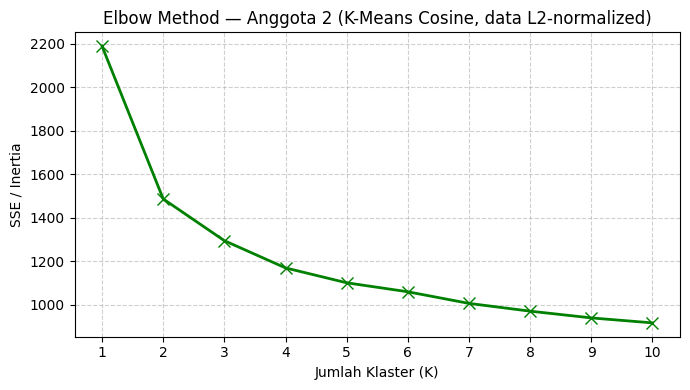

In [ ]:
# BAGIAN B: ELBOW METHOD (menggunakan data L2 untuk konsistensi)

K_range = range(1, 11)
sse     = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_l2)
    sse.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), sse, 'gx-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('SSE / Inertia')
plt.title('Elbow Method — Anggota 2 (K-Means Cosine, data L2-normalized)')
plt.xticks(list(K_range))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('a2_elbow.png')
plt.show()

K_TERBAIK = 4  # Ganti sesuai hasil elbow

In [ ]:
# BAGIAN C: K-MEANS COSINE — Latih + Ukur Performa

print("\n" + "="*52)
print("  K-MEANS — METRIK: COSINE")
print("="*52)
print("  (Menggunakan data L2-normalized + KMeans Euclidean)")
print("="*52)

# Mulai ukur memori dan waktu
tracemalloc.start()
t_mulai = time.time()

# Latih KMeans pada data L2 (secara matematis setara cosine)
km_cosine  = KMeans(n_clusters=K_TERBAIK, random_state=42, n_init=10)
lbl_cosine = km_cosine.fit_predict(X_l2)

# Hentikan ukur
t_selesai = time.time()
_, mem_puncak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Silhouette Score dengan metric cosine
sil_cosine = silhouette_score(X_l2, lbl_cosine, metric='cosine')

# Tampilkan Evaluasi
print(f"  Jumlah Klaster    : {K_TERBAIK}")
print(f"  Waktu Eksekusi    : {t_selesai - t_mulai:.4f} detik")
print(f"  Memori Puncak     : {mem_puncak/1024:.2f} KB ({mem_puncak/1024**2:.4f} MB)")
print(f"  Silhouette Score  : {sil_cosine:.4f}")
print("="*52)


  K-MEANS — METRIK: COSINE
  (Menggunakan data L2-normalized + KMeans Euclidean)
  Jumlah Klaster    : 4
  Waktu Eksekusi    : 0.1146 detik
  Memori Puncak     : 623.28 KB (0.6087 MB)
  Silhouette Score  : 0.3363


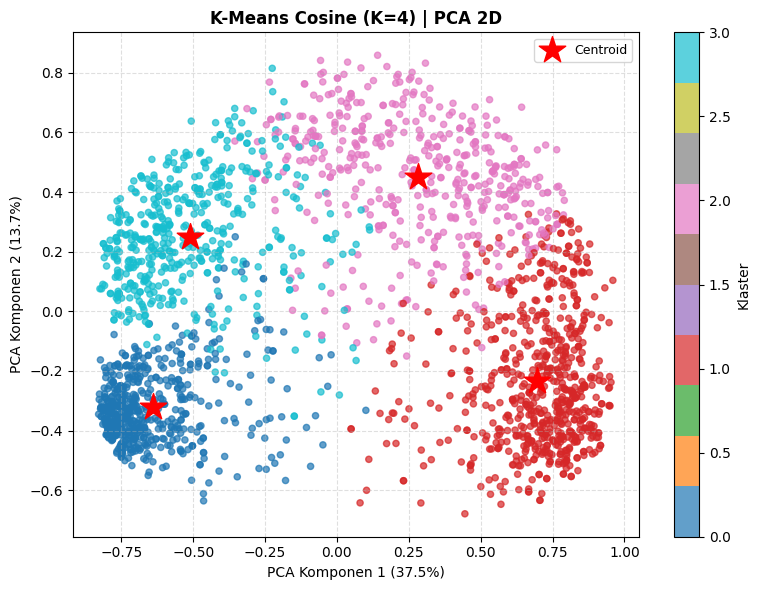

Visualisasi disimpan: 'a2_kmeans_cosine_plot.png'


In [ ]:
# BAGIAN D: VISUALISASI PCA

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_l2)   # PCA dari data L2
v1, v2 = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=lbl_cosine,
                 cmap='tab10', s=20, alpha=0.7)
cen_pca = pca.transform(km_cosine.cluster_centers_)
plt.scatter(cen_pca[:, 0], cen_pca[:, 1], c='red', marker='*',
            s=400, zorder=5, label='Centroid')
plt.colorbar(sc, label='Klaster')
plt.title(f'K-Means Cosine (K={K_TERBAIK}) | PCA 2D',
          fontsize=12, fontweight='bold')
plt.xlabel(f'PCA Komponen 1 ({v1:.1f}%)')
plt.ylabel(f'PCA Komponen 2 ({v2:.1f}%)')
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('a2_kmeans_cosine_plot.png', dpi=150)
plt.show()
print("Visualisasi disimpan: 'a2_kmeans_cosine_plot.png'")